In [29]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,precision_score, recall_score, f1_score


##### Load and Explore the Dataset

In [5]:
# Load the dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(df.shape)
# print(df.head())


(569, 31)


####  Train-Test Split

In [12]:
X = df.drop('target', axis=1)
y = df['target']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(y_test)

204    1
70     0
131    0
431    1
540    1
      ..
486    1
75     0
249    1
238    1
265    0
Name: target, Length: 114, dtype: int64


#####  Feature Scaling (Important for Logistic Regression)

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)


#### Train the Logistic Regression Model

In [28]:
# LogisticRegression

model = LogisticRegression(max_iter=100)

# Train the model
model.fit(X_train_scaled, y_train)



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


##### Make Predictions

In [20]:
y_pred = model.predict(X_test_scaled)


##### Evaluate the Model

In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9736842105263158

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [24]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\n")
print("True Negative: ", tn)
print("false positive:", fp)
print("False Negative: ", fn)
print("True positive: ", tp)

Confusion Matrix:
[[41  2]
 [ 1 70]]


True Negative:  41
false positive: 2
False Negative:  1
True positive:  70


In [25]:
print("Recall score %:", recall_score(y_test, y_pred) *100)

Recall score %: 98.59154929577466


In [26]:
print("Precision score %:", precision_score(y_test, y_pred) *100)

Precision score %: 97.22222222222221


In [27]:
print("F1 score %:", f1_score(y_test, y_pred) *100)

F1 score %: 97.9020979020979


##### Confusion Matrix Visualization

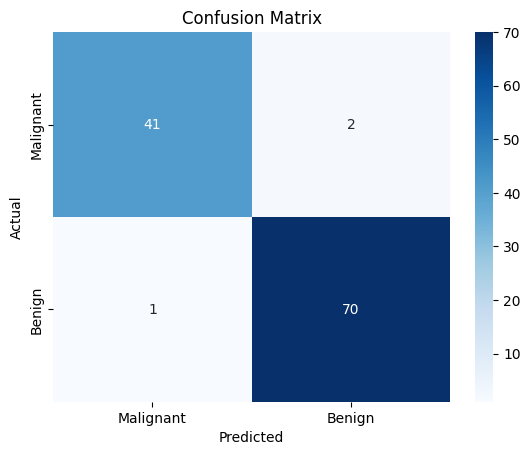

In [30]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


##### Insights from Evaluation: Accuracy > 95% is usually achieved on this dataset.